https://stackoverflow.com/questions/74141355/dimensionality-reduction-autoencoder-pytorch

#### Imports

In [1]:
import importlib
import time
import copy
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import heapq

from sklearn.model_selection import train_test_split
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C, DotProduct, ExpSineSquared
from sklearn.gaussian_process import GaussianProcessRegressor

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

In [2]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Master_Thesis\\utils.py'>

In [3]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [4]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

# first split: train (80%) and temp (20%)
X_tr, X_temp, Y_tr, Y_temp = train_test_split(X, Y_resh, test_size=0.2, shuffle=True, random_state=42)

# second split: validation (10%) and test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=True, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print()
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Gaussian Process Pipeline

<ol>
    <li><b>Dimensionality Reduction</b>: PCA and Kernel PCA are implemented. From testing and research, it can be seen that 10 components already explain over 99.99% of variance.</li>
    <li><b>Scaling</b>: standard scaling and min-max scaling are implemented.</li>
    <li><b>Fit</b> of the Gaussian Processes.</li>
    <li><b>Validation</b> of the Gaussian Processes.</li>
</ol>

In [ ]:
def fit_gp(x_tr_scaled, y_tr_reduced_scaled_list, gp_kernel):
    """
    Fit a Gaussian Process Regressor for each output function using the scaled training data
    - inputs: scaled training inputs, list of scaled PCA-transformed training outputs
    - outputs: list of fitted GaussianProcessRegressor models for each output function and the time taken to fit all GPs
    """

    print("---------- Fitting Gaussian Process Regressor for each output function... ----------")

    # fit Gaussian Process for each function
    gpr_list = []

    # start measuring time
    start_time_fit = time.time()
    for i in range(globals.N_FUNCTIONS):
        # more than 0 restarts causes a huge increase in fitting time without significant improvement in performance
        gpr = GaussianProcessRegressor(kernel=copy.deepcopy(gp_kernel), n_restarts_optimizer=0, random_state=42)
        gpr.fit(x_tr_scaled, y_tr_reduced_scaled_list[i])
        print("Learned kernel:", gpr.kernel_)
        gpr_list.append(gpr)
    end_time_fit = time.time()
    print(f"Time taken to fit GPs: {end_time_fit - start_time_fit:.2f} seconds")

    print("---------- Gaussian Process fitting completed. ----------\n")

    return gpr_list, end_time_fit - start_time_fit

In [ ]:
def validate_gp(gpr_list, x_val_scaled, y_val, wavelengths, y_scalers, pca_list):
    """
    Validate the fitted Gaussian Process models on the validation set
    - inputs: list of fitted GaussianProcessRegressor models, scaled validation inputs, list of scaled PCA-transformed validation outputs, list of scalers used for each output function, list of PCA objects for each output function
    - outputs: numpy array of predicted outputs on the validation set in the original space (n_samples, 6, 4205)
    """

    print("---------- Validating Gaussian Process models on the validation set... ----------")

    # predictions on validation set
    y_val_pred = np.zeros_like(y_val)  # (n_samples, 6, 4205)
    for i in range(globals.N_FUNCTIONS):
        y_pred_red_scaled = gpr_list[i].predict(x_val_scaled) # predictions in reduced and scaled space
        y_pred_red = y_scalers[i].inverse_transform(y_pred_red_scaled)  # inverse scaling
        y_pred = pca_list[i].inverse_transform(y_pred_red)  # inverse PCA
        y_val_pred[:, i, :] = y_pred

    print("y_val_pred shape:", y_val_pred.shape)

    # MRE calculation
    mre = utils.mre_score(y_val, y_val_pred, wavelengths)
    print(f"----- Validation MRE: {mre} -----")

    print("---------- Validation completed. ----------\n")

    return mre

Apply the whole pipeline.

In [7]:
# gp kernels
n_feat = X_tr.shape[1]

kern_rbf = (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=np.ones(n_feat), length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

kern_matern = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(n_feat),
        length_scale_bounds=(1e-3, 1e3),
        nu=2.5
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_rq = (
    C(1.0, (1e-3, 1e3))
    * RationalQuadratic(
        length_scale=1.0,
        alpha=1.0,
        length_scale_bounds=(1e-3, 1e3),
        alpha_bounds=(1e-3, 1e3)
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_rbf_rq = (
    C(1.0, (1e-3, 1e3))
    * (
        RBF(
            length_scale=np.ones(n_feat),
            length_scale_bounds=(1e-3, 1e3)
        )
        + RationalQuadratic(
            length_scale=1.0,
            alpha=1.0
        )
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_dot_rbf = (
    C(1.0, (1e-3, 1e3))
    * (
        DotProduct()
        + RBF(
            length_scale=np.ones(n_feat),
            length_scale_bounds=(1e-3, 1e3)
        )
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_linear = (
    C(1.0, (1e-3, 1e3))
    * DotProduct()
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_matern_rq = (
    C(1.0, (1e-3, 1e3))
    * (
        Matern(
            length_scale=np.ones(n_feat),
            nu=1.5
        )
        + RationalQuadratic()
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

In [ ]:
# param_grid = {
#     "kernel": [None, "rbf", "sigmoid", "poly"],
#     "gamma": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
#     "alpha": [1e-3, 1e-2, 1e-1, 1],
#     "degree": [2, 3, 4],
#     "scale_type": ["standard", "minmax"]
# }
param_grid = { # for quick testing
    "pca_kernel": [None],
    "gamma": [1e-2],
    "alpha": [1e-1],
    "degree": [3],
    "scale_type": ["standard", "minmax"],
    "gp_kernel": [kern_rbf, kern_matern, kern_rq, kern_rbf_rq, kern_dot_rbf, kern_linear, kern_matern_rq]
}

last_id = utils.load_csv_last_id("gp_results.csv")
top_results = []  # store (mre, parameters, gpr_list)

for pca_kernel in param_grid["pca_kernel"]:

    # if regular PCA is used, gamma and alpha are irrelevant
    if pca_kernel is None:
        gamma_values = [None]
        alpha_values = [None]
    else:
        gamma_values = param_grid["gamma"]
        alpha_values = param_grid["alpha"]

    if pca_kernel != "poly":
        degree_values = [0]
    else:
        degree_values = param_grid["degree"]

    for gamma in gamma_values:
        for alpha in alpha_values:
            for degree in degree_values:
                for scale_type in param_grid["scale_type"]:
                    for gp_kernel in param_grid["gp_kernel"]:
                        start_time_pipeline = time.time()
                        gp_kernel_name = str(gp_kernel).replace(" ", "")
                        print(f"========== Running GP pipeline with pca_kernel={pca_kernel}, gamma={gamma}, alpha={alpha}, degree={degree}, scale_type={scale_type} and gp_kernel={gp_kernel_name}... ==========")

                        # dimensionality reduction
                        pca_list, Y_tr_pca_list = utils.apply_pca(Y_tr, n_components=10, kernel=pca_kernel, gamma=gamma, alpha=alpha, degree=degree)

                        # scaling
                        X_tr_scaled, X_val_scaled, x_scaler = utils.scale_input_data(X_tr, X_val, scale_type=scale_type)
                        Y_tr_reduced_scaled_list, y_scalers = utils.scale_output_data(Y_tr_pca_list, scale_type=scale_type)

                        # fit Gaussian Process
                        gpr_list, gp_fit_time = fit_gp(X_tr_scaled, Y_tr_reduced_scaled_list, gp_kernel)

                        # validate Gaussian Process
                        mre = validate_gp(gpr_list, X_val_scaled, Y_val, wavelengths, y_scalers, pca_list)

                        # save best model based on MRE
                        entry = (mre, {
                            "pca_kernel": pca_kernel,
                            "gamma": gamma,
                            "alpha": alpha,
                            "degree": degree,
                            "scale_type": scale_type,
                            "gp_kernel": gp_kernel_name
                        }, gpr_list, pca_list, x_scaler, y_scalers)

                        heapq.heappush(top_results, entry)

                        # keep only best 5 (smallest MRE)
                        top_results = heapq.nsmallest(5, top_results, key=lambda x: x[0])

                        # write parameters and MRE to csv file
                        end_time_pipeline = time.time()
                        results_df = pd.DataFrame({
                            "id": [last_id + 1],
                            "pca_kernel": [pca_kernel if pca_kernel is not None else "None"],
                            "gamma": [gamma if gamma is not None else "None"],
                            "alpha": [alpha if alpha is not None else "None"],
                            "degree": [degree if degree != 0 else "None"],
                            "scale_type": [scale_type],
                            "gp_kernel": [gp_kernel_name],
                            "fit_time": [gp_fit_time],
                            "total_time": [end_time_pipeline - start_time_pipeline],
                            "mre": [mre]
                        })
                        results_df.to_csv("gp_results.csv", mode="a", header=not Path("gp_results.csv").exists(), index=False)
                        last_id += 1
                        print("================================================== GP pipeline completed. ==================================================\n")

========== Running GP pipeline with pca_kernel=None, gamma=None, alpha=None, degree=0, scale_type=standard and gp_kernel=1**2*RBF(length_scale=[1,1,1,1,1,1,1,1,1])+WhiteKernel(noise_level=0.01)... ==========
---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------

---------- Scaling input data using standard scaling... ----------
---------- Input data scaling complete

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 4.26**2 * RBF(length_scale=[24.6, 2.36, 5.88, 1e+03, 3.69, 1e+03, 1.68, 8.14, 2.07]) + WhiteKernel(noise_level=0.00459)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 10.8**2 * RBF(length_scale=[53, 2.42, 5.12, 40.2, 6.25, 56.7, 4.53, 354, 1e+03]) + WhiteKernel(noise_level=0.00103)
Learned kernel: 5.96**2 * RBF(length_scale=[166, 3.17, 3.21, 12.8, 4.18, 29.6, 5.56, 581, 11.5]) + WhiteKernel(noise_level=0.00568)


...

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 5.6**2 * Matern(length_scale=[3.61e+03, 12.6, 10.3, 40.7, 15, 77.6, 24.8, 8.46e+04, 56.9], nu=1.5) + RationalQuadratic(alpha=62.1, length_scale=313) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may 

Learned kernel: 5.24**2 * Matern(length_scale=[1e+05, 6.01, 18.9, 1e+05, 11.9, 8.59e+04, 1e+05, 211, 8.49e+04], nu=1.5) + RationalQuadratic(alpha=789, length_scale=10.1) + WhiteKernel(noise_level=1e-05)
Learned kernel: 2.47**2 * Matern(length_scale=[1e+05, 6.46, 9.77, 97.6, 7.4, 1e+05, 9.8, 162, 12.5], nu=1.5) + RationalQuadratic(alpha=0.112, length_scale=12.1) + WhiteKernel(noise_level=1e-05)
Time taken to fit GPs: 70.97 seconds
---------- Gaussian Process fitting completed. ----------

---------- Validating Gaussian Process models on the validation set... ----------
y_val_pred shape: (50, 6, 4205)
NaN values in y_val_pred: 0
----- Validation MRE: 0.003420641180127859 -----
---------- Validation completed. ----------

================================================== GP pipeline completed. ==================================================



c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a bette

In [10]:
# load and analyze csv results
df_results = pd.read_csv("gp_results.csv")

# ordered barplot of MRE for each parameter combination
df_results = df_results.sort_values(by="mre")
print("Best 5 parameter combinations based on MRE:")
df_results.head(5)

Best 5 parameter combinations based on MRE:


,id,pca_kernel,gamma,alpha,degree,scale_type,gp_kernel,fit_time,total_time,mre
8,9,NaN,NaN,NaN,NaN,minmax,"1**2*Matern(length_scale=[1,1,1,1,1,1,1,1,1],n...",11.754536,11.841534,0.002448
1,2,NaN,NaN,NaN,NaN,standard,"1**2*Matern(length_scale=[1,1,1,1,1,1,1,1,1],n...",15.278065,15.365165,0.002575
7,8,NaN,NaN,NaN,NaN,minmax,"1**2*RBF(length_scale=[1,1,1,1,1,1,1,1,1])+Whi...",9.111703,9.201210,0.003052
10,11,NaN,NaN,NaN,NaN,minmax,"1**2*RBF(length_scale=[1,1,1,1,1,1,1,1,1])+Rat...",26.212477,26.307987,0.003087
11,12,NaN,NaN,NaN,NaN,minmax,1**2*DotProduct(sigma_0=1)+RBF(length_scale=[1...,19.083277,19.177516,0.003124


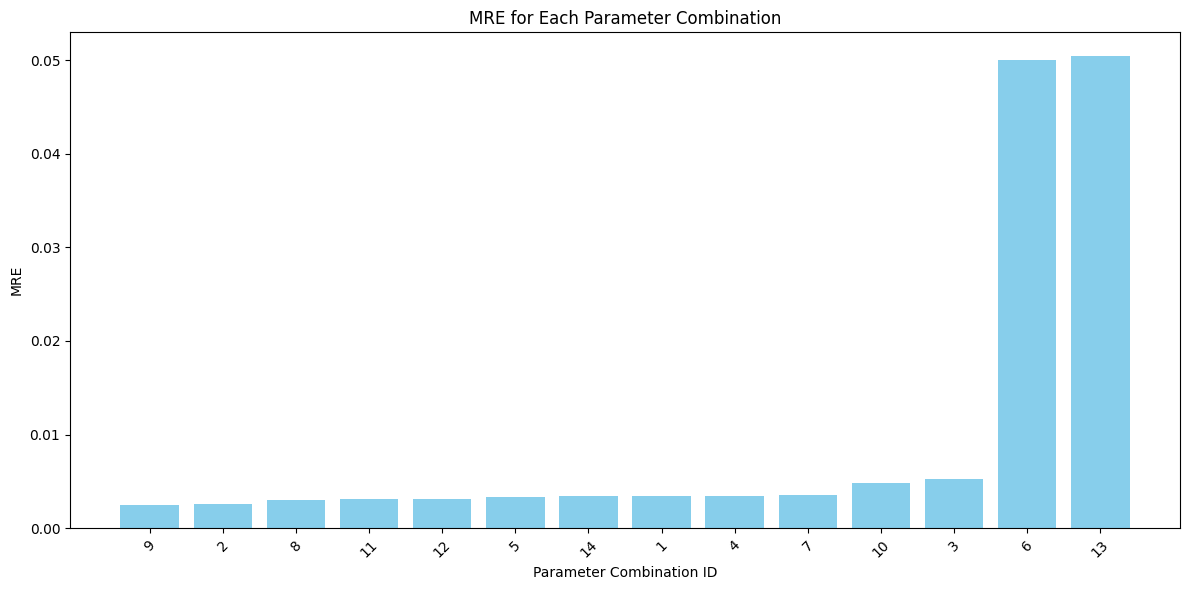

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(range(len(df_results)), df_results["mre"], color="skyblue")
plt.xlabel("Parameter Combination ID")
plt.ylabel("MRE")
plt.title("MRE for Each Parameter Combination")
plt.xticks(range(len(df_results)), df_results["id"], rotation=45)
plt.tight_layout()
plt.show()

Further testing: global average MRE, MRE for each function, MRE for each wavelength, MRE for each function for each wavelength on the external test set.

In [12]:
best_5_mre = [r[0] for r in top_results]
best_5_parameters = [r[1] for r in top_results]
best_5_gpr_lists = [r[2] for r in top_results]
best_5_pca_lists = [r[3] for r in top_results]
best_5_x_scalers = [r[4] for r in top_results]
best_5_y_scalers = [r[5] for r in top_results]

In [14]:
# predict on test set with chosen model
idx = 0
Y_test_pred = np.zeros_like(Y_test)  # (n_samples, 6, 4205)
Y_test_std = np.zeros_like(Y_test)  # (n_samples, 6, 4205)
X_test_scaled = best_5_x_scalers[idx].transform(X_test) # scale test inputs with the same scaler used for training

for i in range(globals.N_FUNCTIONS):
    # 1. Get Latent Predictions and Uncertainty
    # y_pred_red_scaled: (n_samples, n_components)
    # y_std_red_scaled:  (n_samples, n_components)
    Y_pred_red_scaled, Y_std_red_scaled = best_5_gpr_lists[idx][i].predict(X_test_scaled, return_std=True)

    # 2. Inverse Scaling
    Y_pred_red = best_5_y_scalers[idx][i].inverse_transform(Y_pred_red_scaled)
    
    # Scale the standard deviation based on the scaler type
    if str(best_5_y_scalers[idx][i]) == "StandardScaler()":
        Y_std_red = Y_std_red_scaled * best_5_y_scalers[idx][i].scale_
    else: # MinMaxScaler
        Y_std_red = Y_std_red_scaled * (best_5_y_scalers[idx][i].data_max_ - best_5_y_scalers[idx][i].data_min_)

    # 3. Inverse PCA Reconstruction
    Y_pred = best_5_pca_lists[idx][i].inverse_transform(Y_pred_red)

    # 4. Propagate Variance through PCA
    # W is the components matrix: (n_components, n_wavelengths)
    W = best_5_pca_lists[idx][i].components_
    
    # Variance in original space: Var(Y) = W^T * Var(Z) * W 
    # Since we treat components as independent, this simplifies:
    # y_std_full[wavelength] = sqrt( sum( W[comp, wavelength]^2 * latent_var[comp] ) )
    latent_var = Y_std_red**2  # shape (n_samples, n_components)

    # Matrix multiplication to get variance per wavelength: (n_samples, n_wavelengths)
    # (n_samples, n_components) @ (n_components, n_wavelengths)
    Y_var_full = latent_var @ (W**2)
    Y_std_full = np.sqrt(Y_var_full)

    # 5. Store Results
    Y_test_pred[:, i, :] = Y_pred
    Y_test_std[:, i, :] = Y_std_full

Testing MRE: 0.002302368
Lp0 MRE: 0.0056
Edir0 MRE: 0.0011
Edif0 MRE: 0.0025
S MRE: 0.0025
tdir MRE: 0.0002
tdif MRE: 0.0019


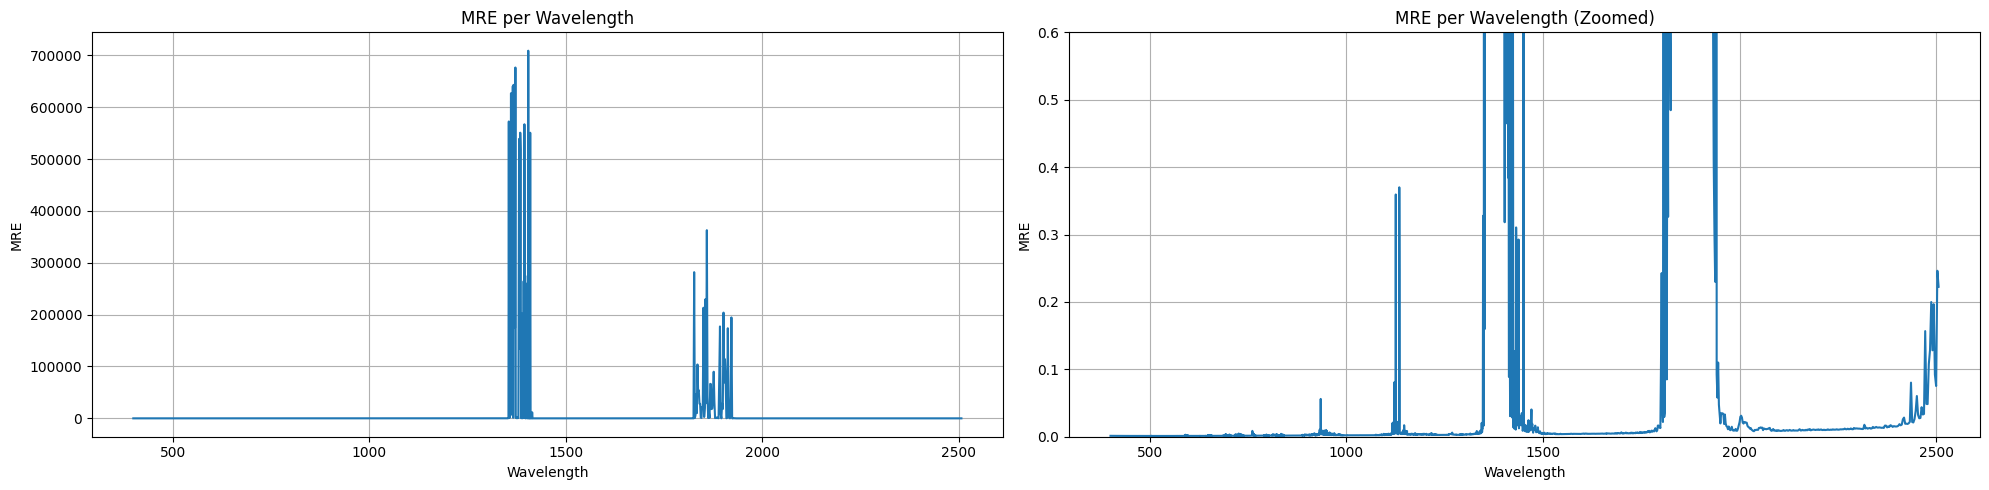

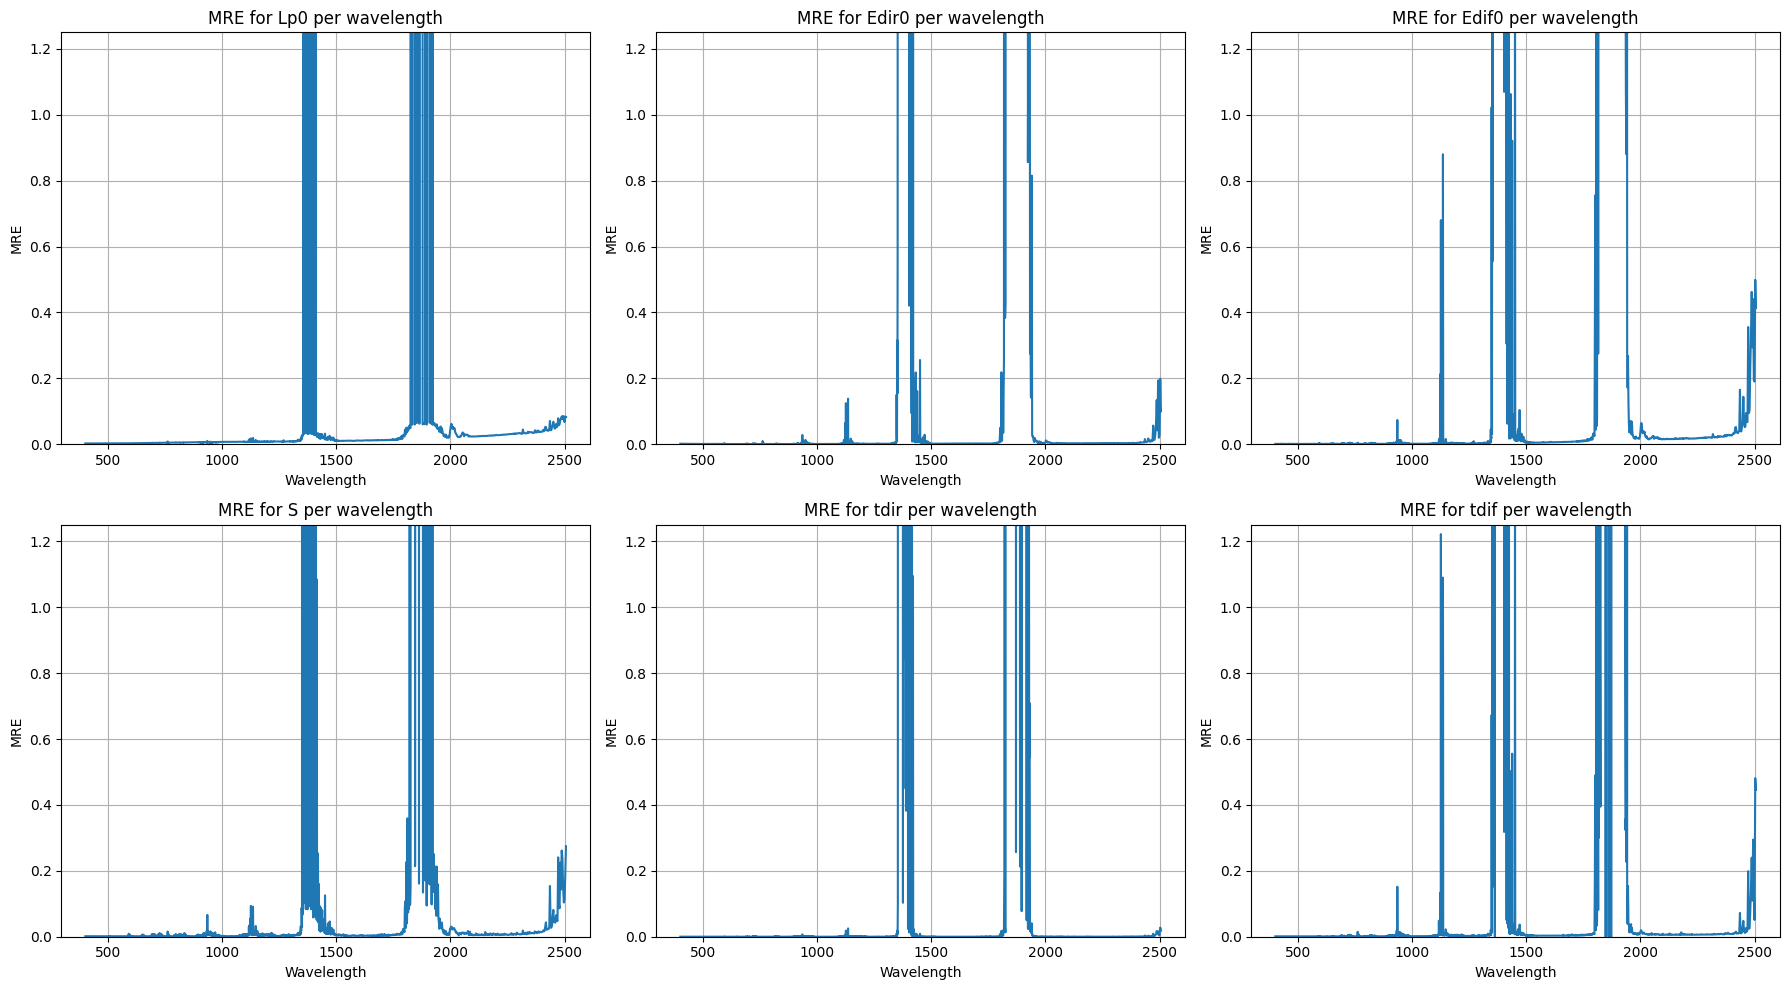

In [15]:
mre = utils.mre_score(Y_test, Y_test_pred, wavelengths)
print("Testing MRE:", mre)

mre_per_func = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names[i]} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].plot(wavelengths, mre_per_wvl)
axes[0].set_xlabel("Wavelength")
axes[0].set_ylabel("MRE")
axes[0].set_title("MRE per Wavelength")
axes[0].grid()
axes[1].plot(wavelengths, mre_per_wvl)
axes[1].set_ylim(0, 0.6)
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("MRE")
axes[1].set_title("MRE per Wavelength (Zoomed)")
axes[1].grid()
plt.tight_layout()
plt.show()

mre_per_func_wvl = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl[i])
    axes[i].set_ylim(0, 1.25)
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MRE")
    axes[i].set_title(f"MRE for {function_names[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Testing MAE: 0.16865386
Lp0 MAE: 0.0602
Edir0 MAE: 0.6688
Edif0 MAE: 0.2823
S MAE: 0.0002
tdir MAE: 0.0001
tdif MAE: 0.0002


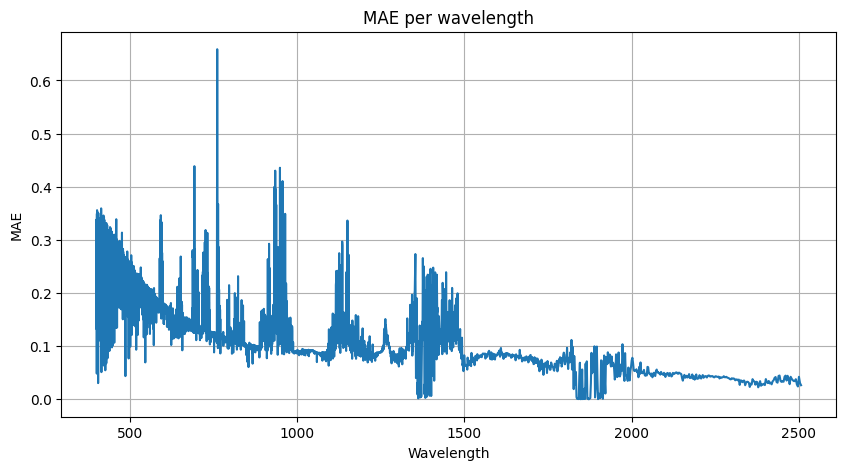

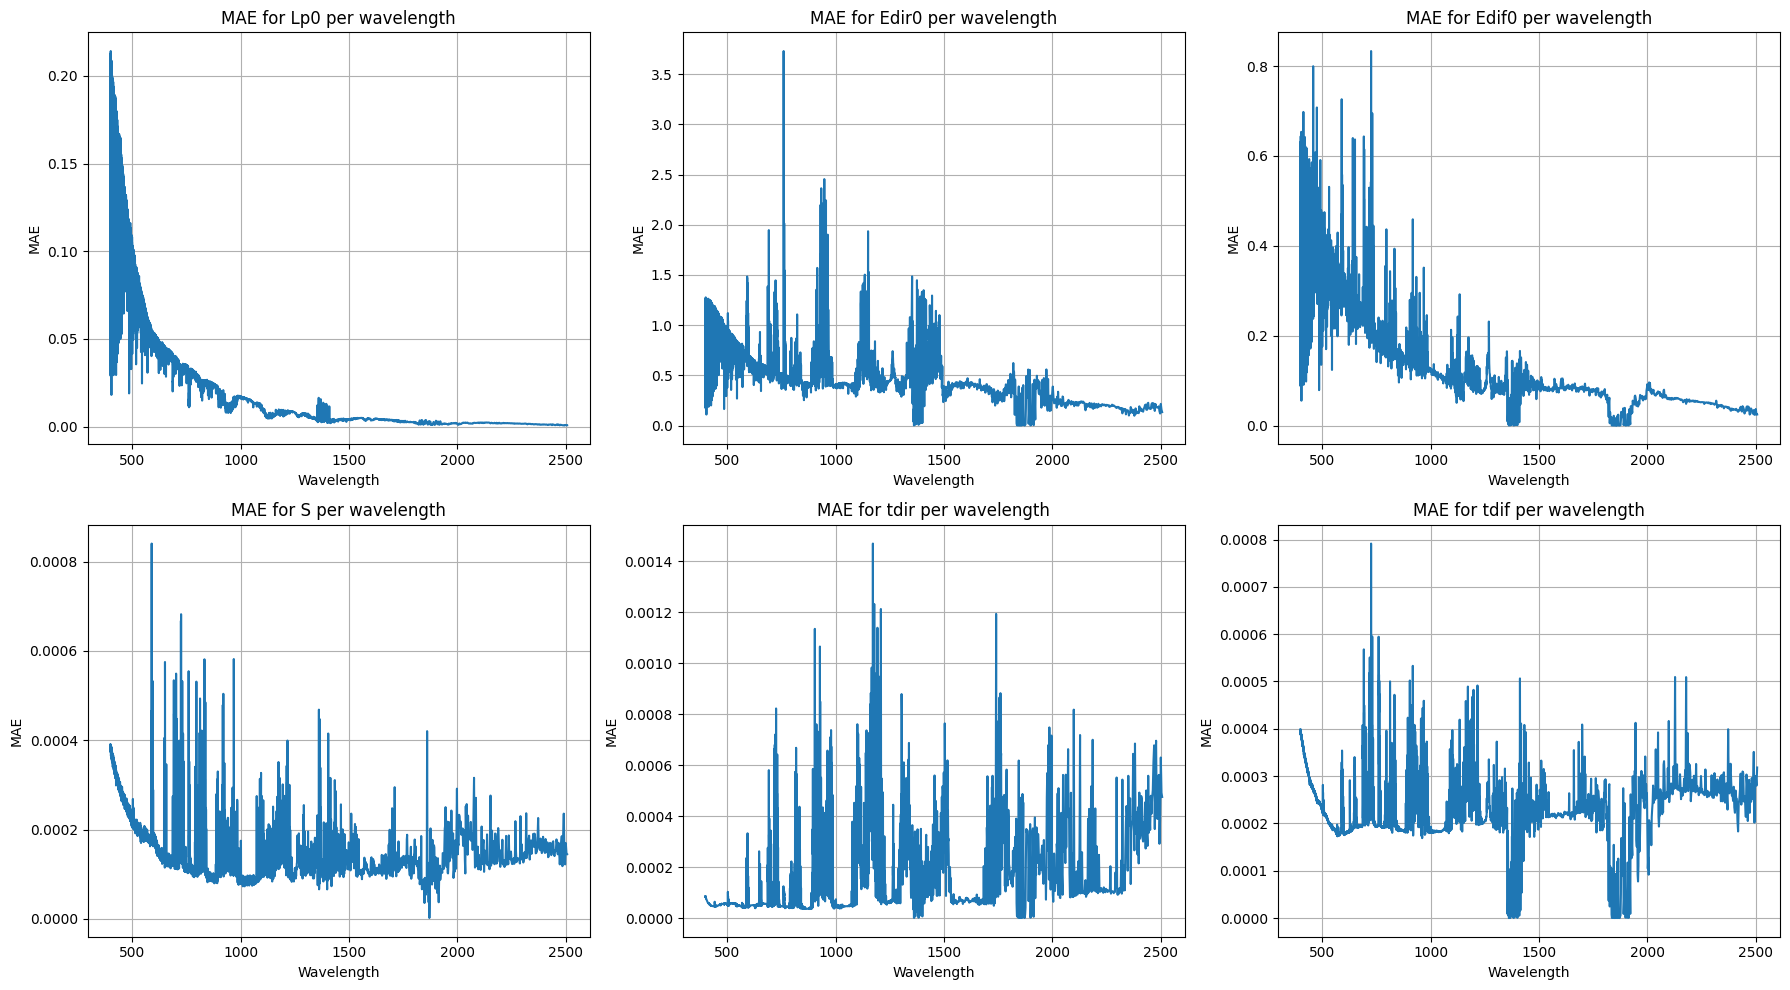

In [23]:
mae = utils.mae_score(Y_test, Y_test_pred, wavelengths)
print("Testing MAE:", mae)

mae_per_func = utils.mae_score(Y_test, Y_test_pred, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names[i]} MAE: {mae_per_func[i]:.4f}")

mae_per_wvl = utils.mae_score(Y_test, Y_test_pred, wavelengths, axis=1)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

mae_per_func_wvl = utils.mae_score(Y_test, Y_test_pred, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mae_per_func_wvl[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MAE")
    axes[i].set_title(f"MAE for {function_names[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Global Coverage Probability (2σ): 97.84%
------------------------------
Lp0             Coverage: 97.72%
Edir0           Coverage: 98.09%
Edif0           Coverage: 96.50%
S               Coverage: 98.46%
tdir            Coverage: 98.23%
tdif            Coverage: 98.06%


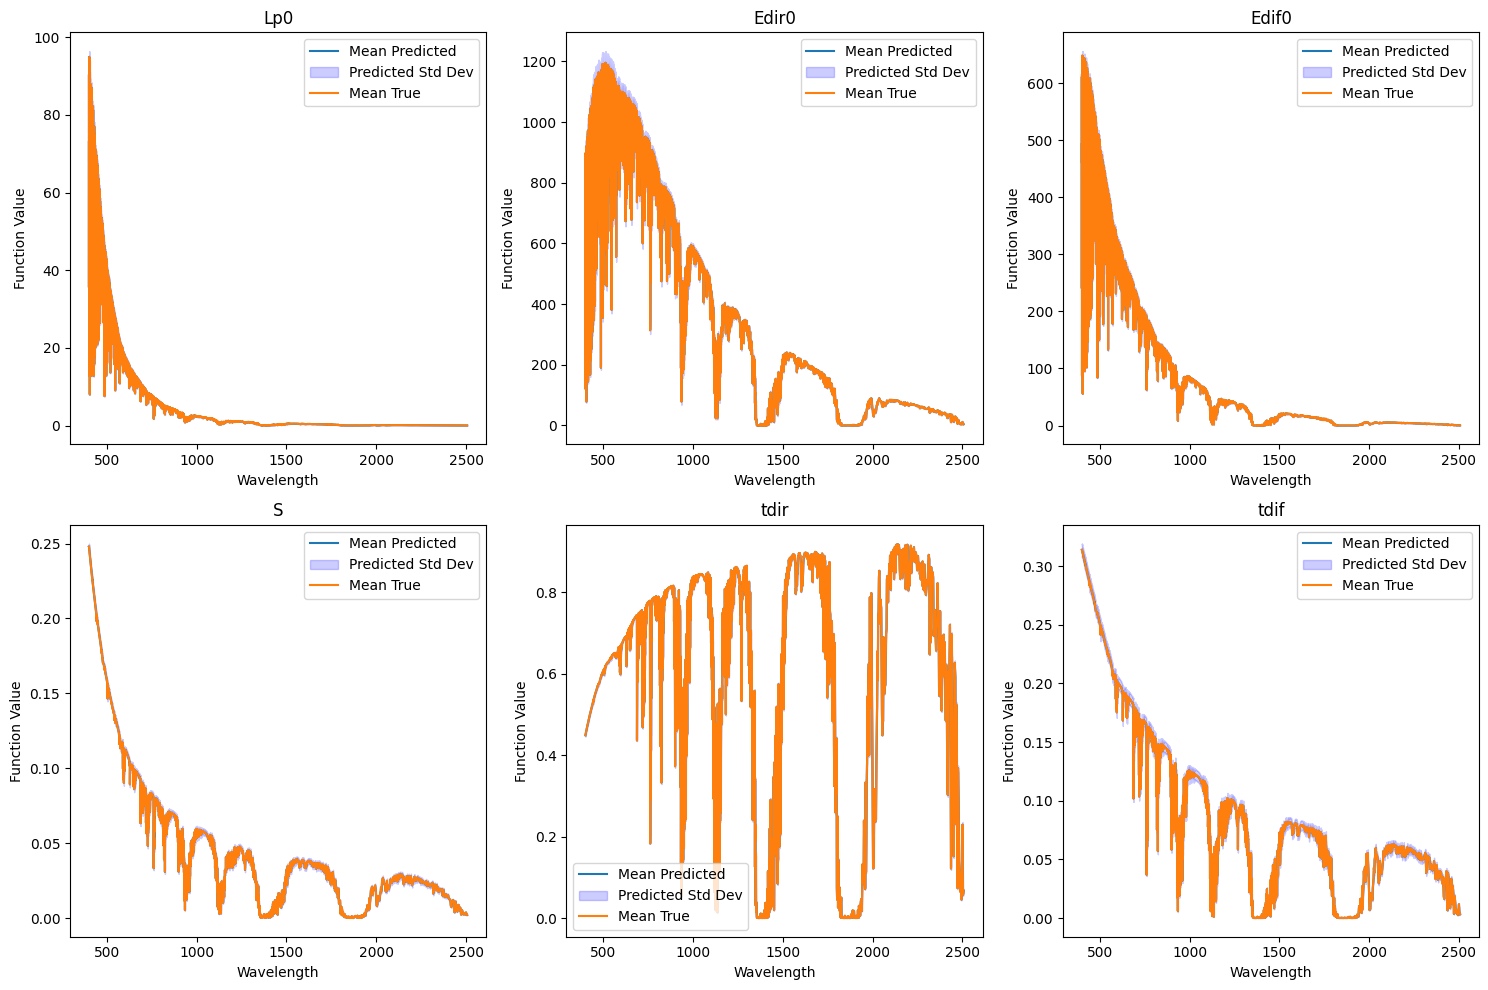

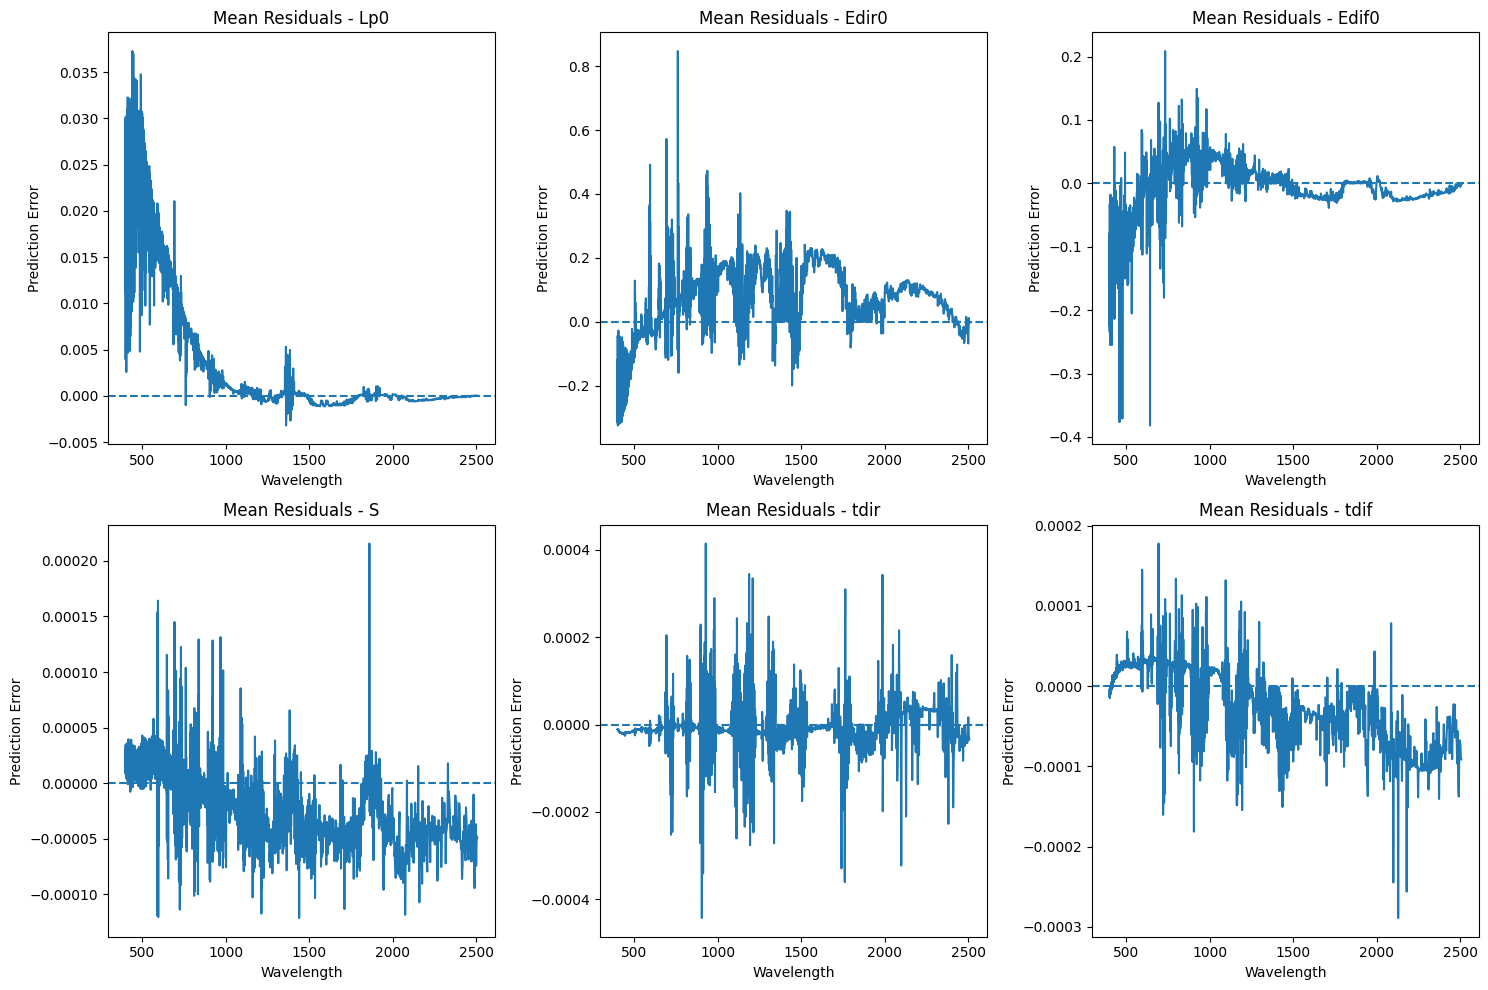

In [24]:
# --- coverage probability ---
global_cov, func_cov = utils.calculate_coverage(Y_test, Y_test_pred, Y_test_std)
print(f"Global Coverage Probability ({2}σ): {global_cov:.2f}%")
print("-" * 30)
for i, name in enumerate(function_names):
    print(f"{name:15} Coverage: {func_cov[i]:.2f}%")


# --- compute mean true and predicted functions across all samples ---
Y_true_mean = np.mean(Y_test, axis=0)        # shape: (6, 4205)
Y_pred_mean = np.mean(Y_test_pred, axis=0)       # shape: (6, 4205)
Y_std_mean = np.mean(Y_test_std, axis=0)        # shape: (6, 4205)

# plot mean true vs predicted
plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")
    # with Gaussian prior, 2 standard deviations should cover ~95% of the true function values
    plt.fill_between(wavelengths, Y_pred_mean[i] - 2 * Y_std_mean[i], Y_pred_mean[i] + 2 * Y_std_mean[i], color="blue", alpha=0.2, label="Predicted Std Dev")
    plt.plot(wavelengths, Y_true_mean[i], label="Mean True")

    plt.title(f"{function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()


# --- residuals for all samples ---
residuals = Y_test_pred - Y_test   # shape: (n_samples, 6, 4205)

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

Load the test csv and apply the model to measure inference runtime.

In [ ]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

# scale test inputs with the same scaler used for training
X_test_csv_scaled = best_5_x_scalers[idx].transform(X_test_csv)

# predict on test CSV with chosen model
Y_test_csv_pred = np.zeros((X_test_csv.shape[0], globals.N_FUNCTIONS, Y_tr.shape[2]))  # (n_samples, 6, 4205)
Y_test_csv_std = np.zeros((X_test_csv.shape[0], globals.N_FUNCTIONS, Y_tr.shape[2]))  # (n_samples, 6, 4205)
start_time_test_csv = time.time()
for i in range(globals.N_FUNCTIONS):
    Y_pred_red_scaled, Y_std_red_scaled = best_5_gpr_lists[idx][i].predict(X_test_csv_scaled, return_std=True) # predictions in reduced and scaled space

    # inverse predictions
    Y_pred_red = best_5_y_scalers[idx][i].inverse_transform(Y_pred_red_scaled)  # inverse scaling
    Y_pred = best_5_pca_lists[idx][i].inverse_transform(Y_pred_red)  # inverse PCA
    Y_test_csv_pred[:, i, :] = Y_pred

    # inverse std
    if str(best_5_y_scalers[idx][i]) == "StandardScaler()":
        Y_std_red = Y_std_red_scaled * best_5_y_scalers[idx][i].scale_
    else: # MinMaxScaler
        Y_std_red = Y_std_red_scaled * (best_5_y_scalers[idx][i].data_max_ - best_5_y_scalers[idx][i].data_min_)
    W = best_5_pca_lists[idx][i].components_ 
    latent_var = Y_std_red**2  # shape (n_samples, n_components)
    Y_var_full = latent_var @ (W**2) 
    Y_std_full = np.sqrt(Y_var_full)
    Y_test_csv_std[:, i, :] = Y_std_full

end_time_test_csv = time.time()
print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", Y_test_csv_pred.shape)
print("Std on test CSV shape:", Y_test_csv_std.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 3.04 seconds
Predictions on test CSV shape: (10000, 6, 4205)
Std on test CSV shape: (10000, 6, 4205)


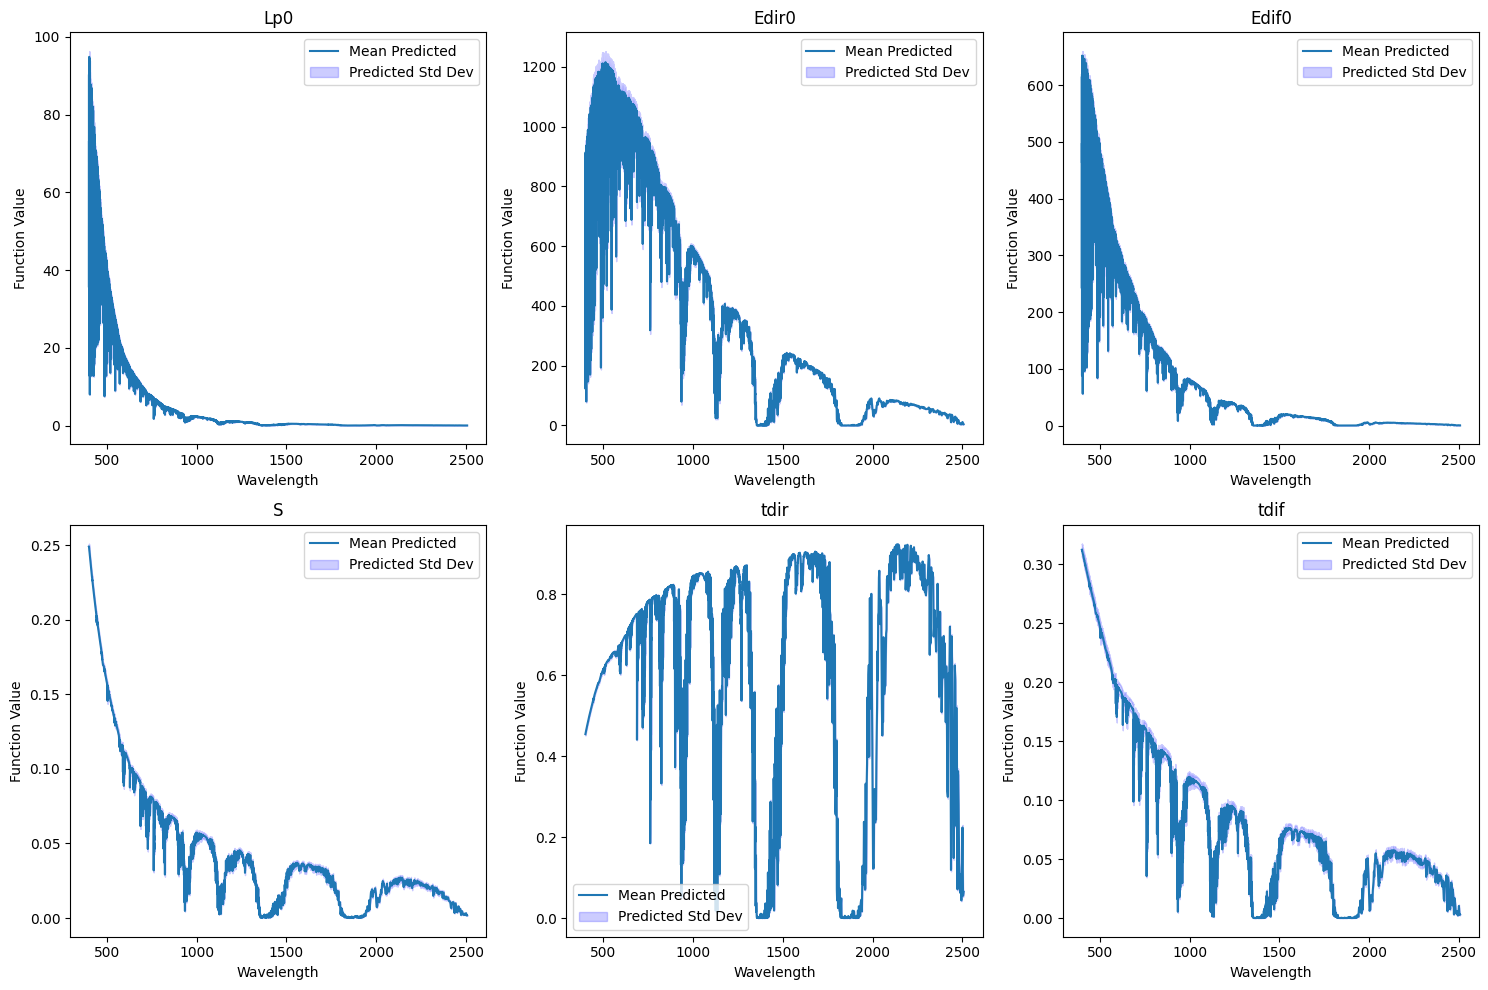

In [ ]:
# compute mean predicted functions across all samples
Y_pred_mean = np.mean(Y_test_csv_pred, axis=0)
Y_std_mean = np.mean(Y_test_csv_std, axis=0)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")
    plt.fill_between(wavelengths, Y_pred_mean[i] - 2 * Y_std_mean[i], Y_pred_mean[i] + 2 * Y_std_mean[i], color="blue", alpha=0.2, label="Predicted Std Dev")

    plt.title(f"{function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()